In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report,  recall_score, precision_score, roc_curve, auc, roc_auc_score

In [2]:
data = pd.read_csv("/content/Telco_Customer_Churn.csv")

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
org_rows = len(data)
data= data.dropna(subset=["TotalCharges"])
print("Total dropped rows with NaNs: ", org_rows - len(data))

Total dropped rows with NaNs:  11


In [6]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges','tenure']
categorical_features =['gender', 'SeniorCitizen', 'Partner', 'Dependents',
                       'PhoneService', 'MultipleLines', 'InternetService',
                      'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
                       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

In [8]:
X = data[numeric_features + categorical_features]
y= data[target_feature]

In [9]:
from collections import Counter
Counter(y)

Counter({'No': 5163, 'Yes': 1869})

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test,y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [11]:
y_train = y_train.map({'Yes':1, 'No': 0})
y_test = y_test.map({'Yes':1, 'No': 0})
y = y.map({'Yes':1, 'No': 0})

In [12]:
y_train

,Churn
5846,0
4416,0
3428,1
3441,0
4338,0
...,...
5485,0
6114,0
5735,0
2520,0


In [13]:
print(y.mean(), y_train.mean(),y_test.mean())

0.26578498293515357 0.2657456318569687 0.26587677725118486


In [14]:
from sklearn.compose import ColumnTransformer


numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='drop'
)




clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42
    ))
])

In [15]:
clf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [16]:
y_predict = clf_pipeline.predict(X_test)
y_predict

array([0, 0, 1, ..., 1, 0, 1])

In [17]:
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
y_proba

array([0.2024585 , 0.0580411 , 0.68354386, ..., 0.89437395, 0.01378753,
       0.80888925])

In [18]:
recall_score(y_test, y_predict)

0.8074866310160428

In [19]:
confusion_matrix(y_test, y_predict)

array([[1152,  397],
       [ 108,  453]])

In [20]:
precision_score(y_test, y_predict)

0.5329411764705883

In [21]:
accuracy_score(y_test, y_predict)

0.7606635071090048

In [22]:
f1_score(y_test, y_predict)

0.6420978029766123

In [23]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1549
           1       0.53      0.81      0.64       561

    accuracy                           0.76      2110
   macro avg       0.72      0.78      0.73      2110
weighted avg       0.81      0.76      0.77      2110



In [24]:
fpr, tpr, threshold = roc_curve(y_test, y_proba)

In [25]:
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8426372485727669


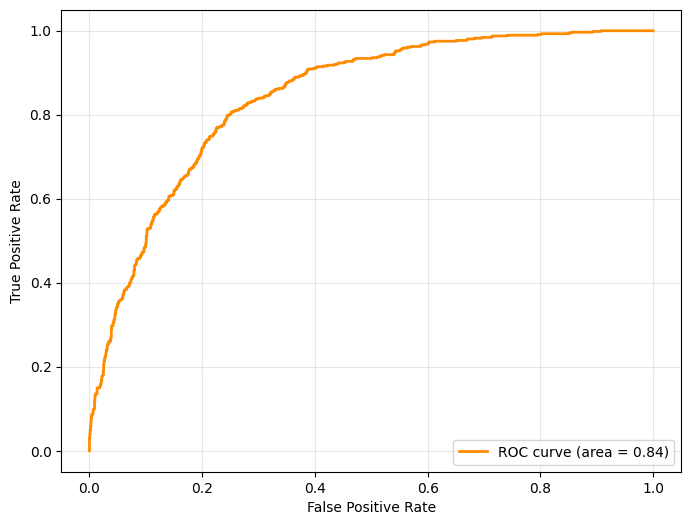

In [26]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [27]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

In [28]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=200, random_state=42))])

In [29]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [30]:
y_pred_rf

array([0, 0, 0, ..., 1, 0, 0])

In [31]:
y_proba_rf

array([0.15 , 0.015, 0.46 , ..., 0.94 , 0.02 , 0.425])

In [32]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1549
           1       0.61      0.44      0.51       561

    accuracy                           0.78      2110
   macro avg       0.71      0.67      0.68      2110
weighted avg       0.76      0.78      0.76      2110



In [33]:
recall_score(y_test, y_pred_rf)

0.4385026737967914

In [34]:
recall_score(y_test, y_pred_rf)

0.4385026737967914

In [35]:
print(confusion_matrix(y_test, y_pred_rf))

[[1394  155]
 [ 315  246]]


In [36]:
fpr_rf, tpr_rf, threshold_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.8215754169500419


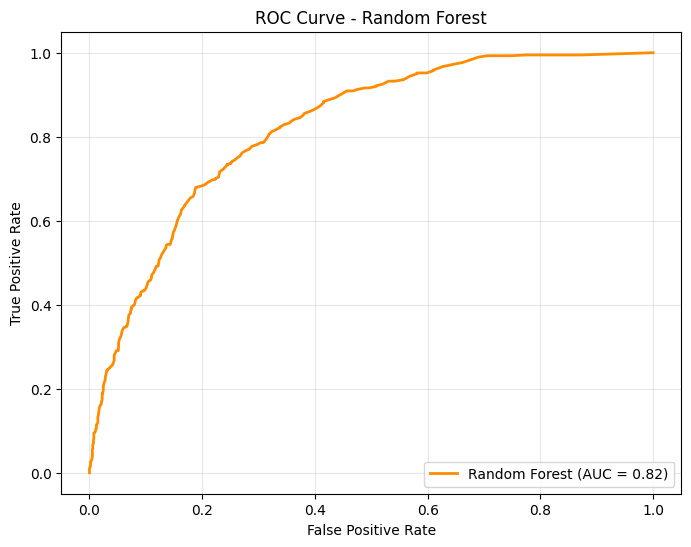

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [38]:
from sklearn.model_selection import cross_val_score

In [39]:
cv_auc = cross_val_score(
        clf_pipeline, X_train, y_train,
        scoring='roc_auc',
        cv=5
)

print("Logistic: ", cv_auc.mean())

Logistic:  0.8448130098816238


In [40]:
cv_auc = cross_val_score(
        rf_model, X_train, y_train,
        scoring='roc_auc',
        cv=5
)

print("Random Forest: ", cv_auc.mean())

Random Forest:  0.8228481052436107


In [41]:
from sklearn.model_selection import GridSearchCV

In [42]:
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [43]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose = 2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['MonthlyCharges',
                                                                          'TotalCharges',
                                                                          'tenure']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='i...
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_estimators=200,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 5],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [200, 400]},
             scoring='roc_auc', verbose=2)

In [44]:
print('Best RF param: ', grid_rf.best_params_)
print('Best RF CV AUC: ', grid_rf.best_score_)

Best RF param:  {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC:  0.8463484669873712


In [45]:
best_rf = grid_rf.best_estimator_
print(best_rf)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown=

In [46]:
y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

In [47]:
y_pred_rf

array([0, 0, 1, ..., 1, 0, 1])

In [48]:
y_pred_prob_rf

array([0.27081149, 0.03348544, 0.53225401, ..., 0.92813709, 0.04338615,
       0.66650918])

In [49]:
fpr_rf, tpr_rf, threshold_rf = roc_curve(y_test, y_pred_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8445797357619027
0.7744075829383886
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1549
           1       0.56      0.74      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.76      0.74      2110
weighted avg       0.80      0.77      0.78      2110



In [50]:
best_rf.named_steps['preprocessor'].get_feature_names_out()

array(['num__MonthlyCharges', 'num__TotalCharges', 'num__tenure',
       'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0',
       'cat__SeniorCitizen_1', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No

In [51]:
best_rf.named_steps['model'].feature_importances_

array([0.06766665, 0.09726847, 0.1259614 , 0.00817032, 0.00766997,
       0.00517148, 0.00532851, 0.00797735, 0.00673935, 0.00839335,
       0.00798013, 0.00290488, 0.00273365, 0.00714959, 0.00278215,
       0.00676484, 0.01823271, 0.04819204, 0.00822799, 0.04503481,
       0.00795515, 0.01281739, 0.02138977, 0.0075186 , 0.00848075,
       0.01512447, 0.00699632, 0.00650312, 0.05500362, 0.00611588,
       0.01611166, 0.00586892, 0.01055812, 0.00618594, 0.00758427,
       0.00852395, 0.00861927, 0.1327509 , 0.02176976, 0.06684679,
       0.01100424, 0.01092875, 0.0070016 , 0.00749039, 0.03429013,
       0.00621058])

In [52]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
37,cat__Contract_Month-to-month,0.132751
2,num__tenure,0.125961
1,num__TotalCharges,0.097268
0,num__MonthlyCharges,0.067667
39,cat__Contract_Two year,0.066847
28,cat__TechSupport_No,0.055004
17,cat__InternetService_Fiber optic,0.048192
19,cat__OnlineSecurity_No,0.045035
44,cat__PaymentMethod_Electronic check,0.034290
38,cat__Contract_One year,0.021770


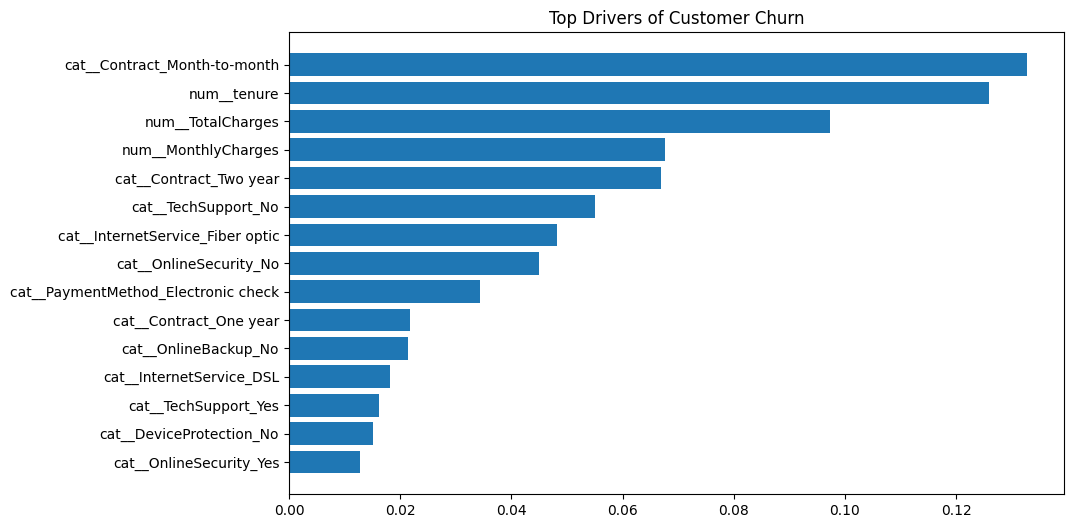

In [53]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [54]:
(importances>=0.09).astype(int)

array([0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0])

In [55]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_prob_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df


,threshold,precision,recall,f1
0,0.10,0.346202,0.991087,0.513152
1,0.15,0.378134,0.967914,0.543816
2,0.20,0.406610,0.942959,0.568206
3,0.25,0.432546,0.914439,0.587293
4,0.30,0.453309,0.891266,0.600962
5,0.35,0.484940,0.860963,0.620424
6,0.40,0.520857,0.823529,0.638122
7,0.45,0.535366,0.782531,0.635771
8,0.50,0.557355,0.736185,0.634409
9,0.55,0.585477,0.689840,0.633388


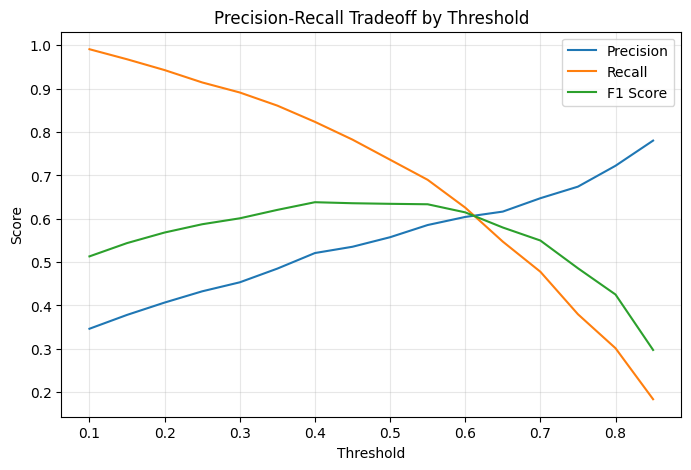

In [56]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

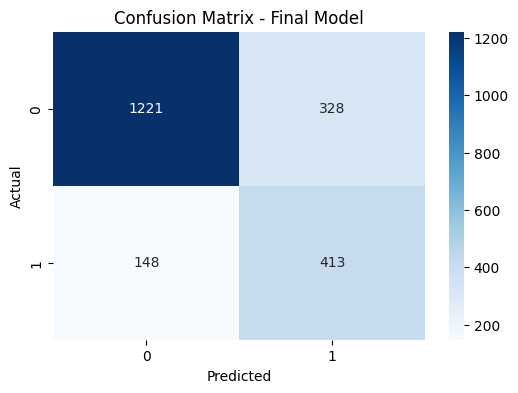

In [57]:
y_pred_final = best_rf.predict(X_test)
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

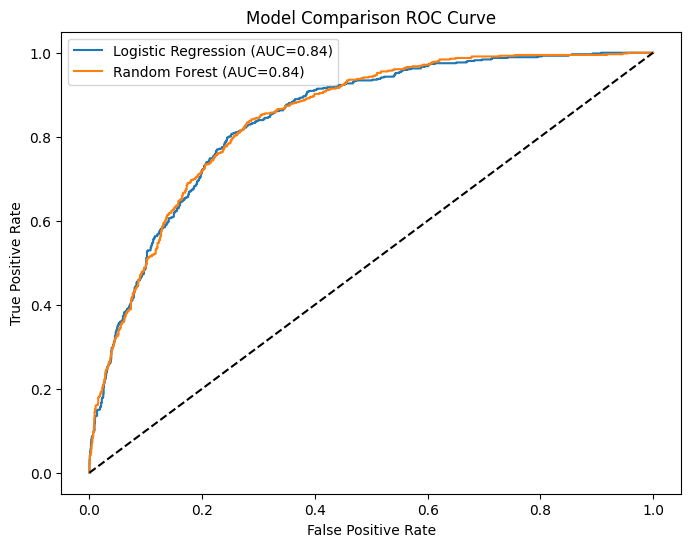

In [58]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [59]:
churn_prob = y_pred_prob_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df['risk_level'] =pd.cut(
    risk_df['churn_probability'],
    bins= [0,0.3,0.6,1],
    labels = ["Low Risk","Medium Risk","High Risk"]
)


risk_df["risk_level"].value_counts()

,count
risk_level,
Low Risk,1007
High Risk,581
Medium Risk,522


In [60]:
import joblib

joblib.dump(clf_pipeline, "logistic_model.pkl")
joblib.dump(best_rf, "rf_model.pkl")

['rf_model.pkl']

In [61]:
best_rf.named_steps['preprocessor'].transform(X_train)

array([[ 0.37505829, -0.89184494, -1.19071605, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.35172274, -0.42197379, -0.6184455 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.96511431,  1.09068524,  0.77135438, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-1.49511925, -0.5925693 ,  0.64872498, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.663419  ,  0.24730414,  0.07645444, ...,  0.        ,
         0.        ,  1.        ],
       [-1.5051202 , -0.94803358, -0.98633371, ...,  0.        ,
         0.        ,  1.        ]])

In [62]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

In [63]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [64]:
feature_names

array(['num__MonthlyCharges', 'num__TotalCharges', 'num__tenure',
       'cat__gender_Female', 'cat__gender_Male', 'cat__SeniorCitizen_0',
       'cat__SeniorCitizen_1', 'cat__Partner_No', 'cat__Partner_Yes',
       'cat__Dependents_No', 'cat__Dependents_Yes',
       'cat__PhoneService_No', 'cat__PhoneService_Yes',
       'cat__MultipleLines_No', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_DSL',
       'cat__InternetService_Fiber optic', 'cat__InternetService_No',
       'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No

In [65]:
rf_classifier = best_rf.named_steps['model']

In [66]:
rf_classifier

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=400, random_state=42)

In [67]:
explainer = shap.TreeExplainer(rf_classifier)

In [68]:
explainer

In [69]:
shap_values = explainer.shap_values(X_train_transformed)

In [70]:
len(shap_values[0])

46

In [71]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)

<class 'numpy.ndarray'>
4922
(46, 2)
(4922, 46)


In [72]:
shap_values

array([[[ 0.00404443, -0.00404443],
        [-0.02275727,  0.02275727],
        [-0.06990275,  0.06990275],
        ...,
        [-0.0020331 ,  0.0020331 ],
        [-0.02108661,  0.02108661],
        [-0.00332771,  0.00332771]],

       [[ 0.02782396, -0.02782396],
        [ 0.03562254, -0.03562254],
        [ 0.0197125 , -0.0197125 ],
        ...,
        [-0.00072827,  0.00072827],
        [ 0.02970831, -0.02970831],
        [-0.00248878,  0.00248878]],

       [[-0.01110274,  0.01110274],
        [ 0.04697785, -0.04697785],
        [ 0.06896202, -0.06896202],
        ...,
        [-0.00268044,  0.00268044],
        [ 0.03968513, -0.03968513],
        [-0.00144138,  0.00144138]],

       ...,

       [[ 0.02161825, -0.02161825],
        [ 0.01585583, -0.01585583],
        [ 0.04730093, -0.04730093],
        ...,
        [-0.00112235,  0.00112235],
        [ 0.01483111, -0.01483111],
        [ 0.00562807, -0.00562807]],

       [[ 0.01221803, -0.01221803],
        [ 0.02237253, -0.02

In [73]:
shap_values[:, :, 1]

array([[-0.00404443,  0.02275727,  0.06990275, ...,  0.0020331 ,
         0.02108661,  0.00332771],
       [-0.02782396, -0.03562254, -0.0197125 , ...,  0.00072827,
        -0.02970831,  0.00248878],
       [ 0.01110274, -0.04697785, -0.06896202, ...,  0.00268044,
        -0.03968513,  0.00144138],
       ...,
       [-0.02161825, -0.01585583, -0.04730093, ...,  0.00112235,
        -0.01483111, -0.00562807],
       [-0.01221803, -0.02237253, -0.03116228, ..., -0.00018637,
        -0.01596049, -0.00509975],
       [-0.0210052 ,  0.00862179,  0.01896639, ...,  0.00140308,
        -0.01489495, -0.00757226]])

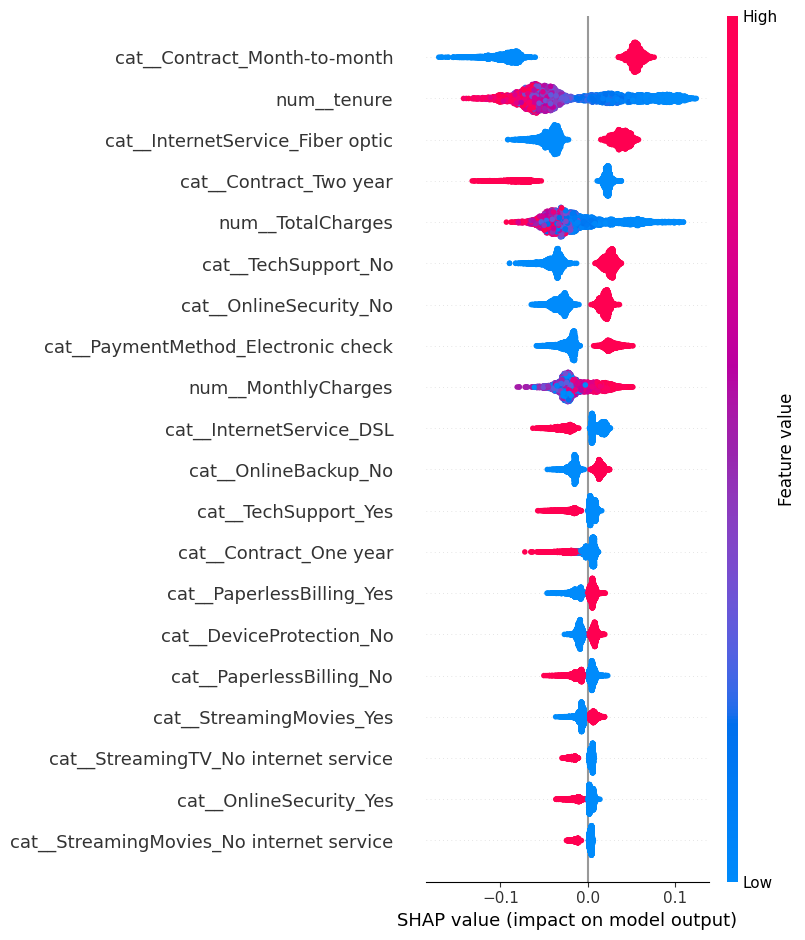

In [74]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

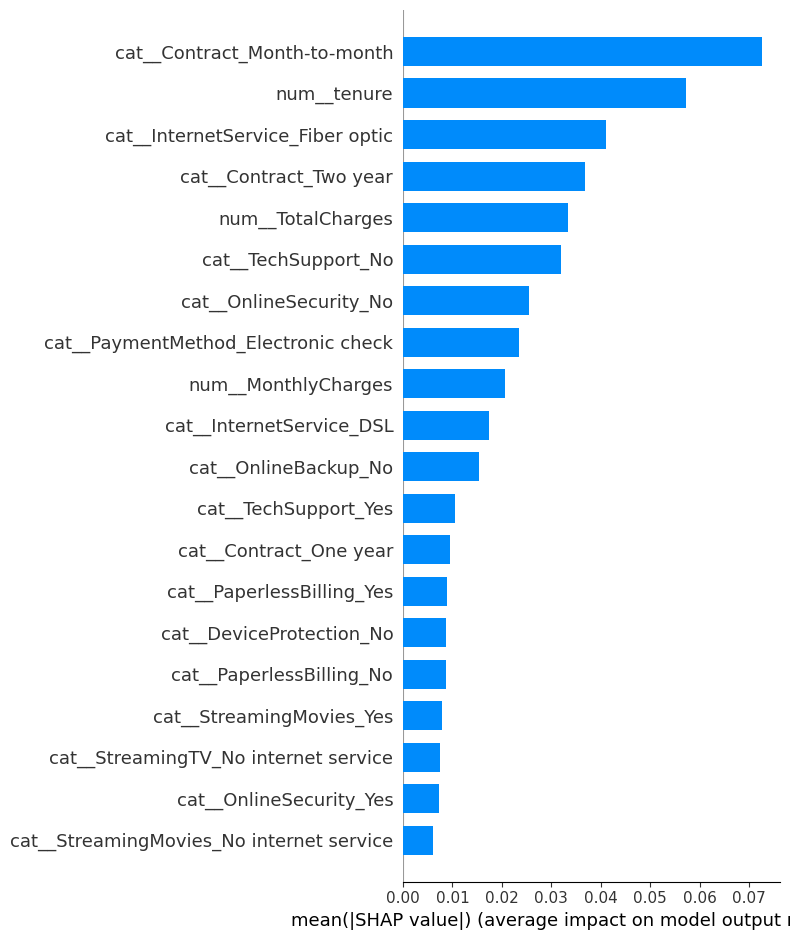

In [75]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

In [76]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [77]:
np.bincount(y_train)

array([3614, 1308])

In [78]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [79]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['MonthlyCharges',
                                                   'TotalCharges', 'tenure']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'Senior...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [80]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1549
           1       0.54      0.78      0.63       561

    accuracy                           0.76      2110
   macro avg       0.72      0.77      0.73      2110
weighted avg       0.81      0.76      0.77      2110

ROC AUC: 0.8437546390115409


In [81]:
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC AUC": [0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb), 2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_pred_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_pred_xgb), 2)],
    "Recall": [0.84, 0.78, round(recall_score(y_test, y_pred_xgb), 2)]
})
performance_df

,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.84,0.63,0.54,0.78


In [82]:
joblib.dump(xgb_model, "xgb_model.pkl")

['xgb_model.pkl']